In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 1. Load Dataset

In [3]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


#### Exploratory Data Analysis

In [5]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

#### Histograms

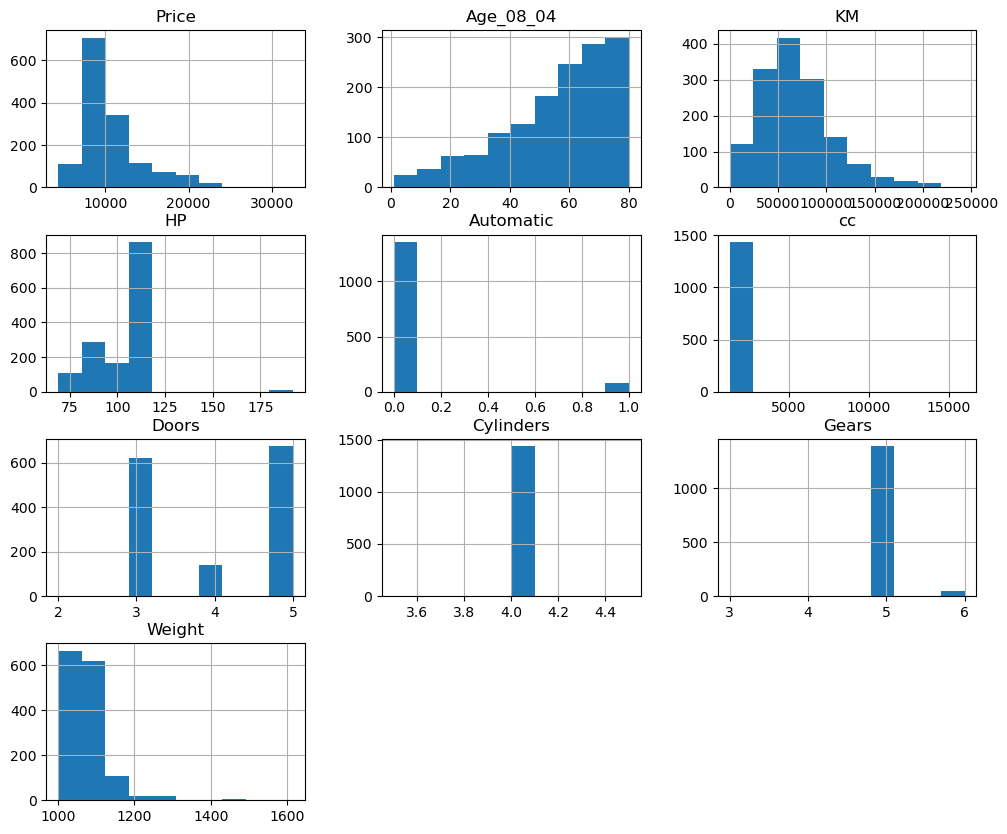

In [7]:
df.hist(figsize=(12,10))
plt.show()

#### Correlation Heatmap

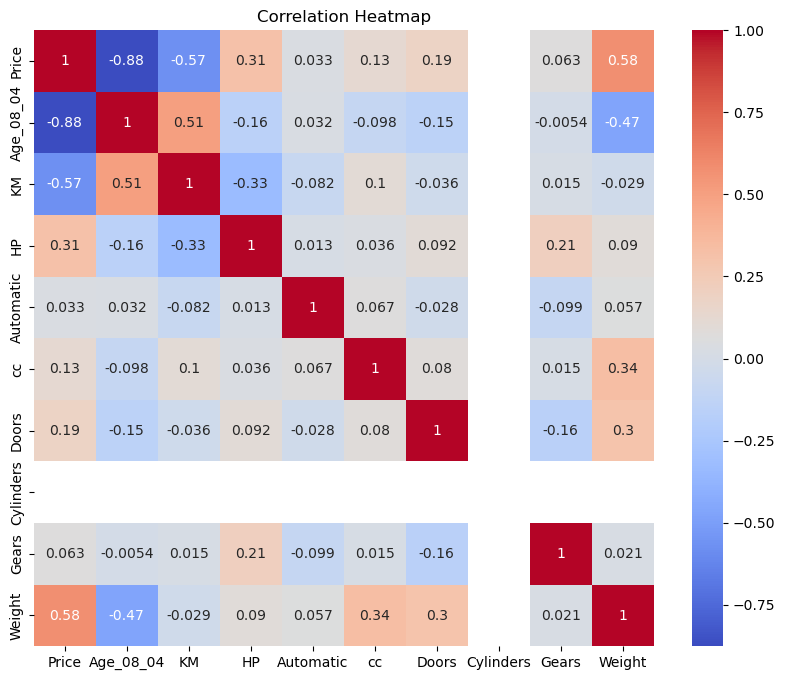

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Pairplot

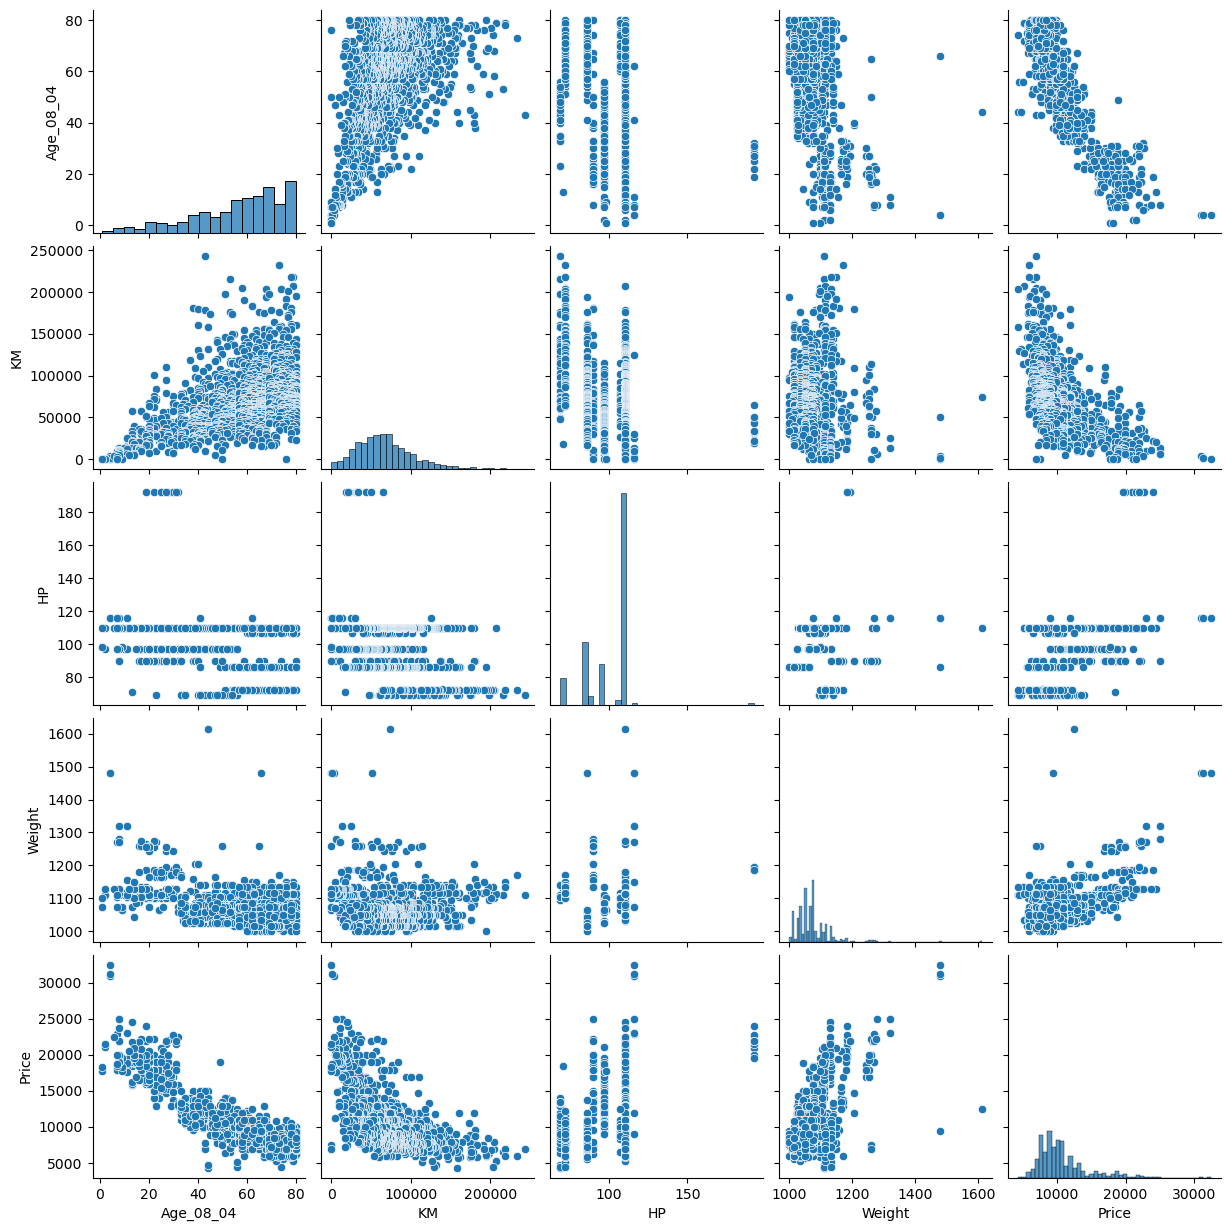

In [9]:
sns.pairplot(df[['Age_08_04','KM','HP','Weight','Price']])
plt.show()

#### Data Preprocessing

##### Convert FuelType into numerical values

In [13]:
le = LabelEncoder()
df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])

##### Features and Target

In [14]:
X = df.drop("Price", axis=1)
y = df["Price"]

#### Standardization

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 2. Split Dataset

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

### 3. Multiple Linear Regression Models

##### Model 1
##### All Features

In [18]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("\nModel 1 Coefficients")
for feature, coef in zip(X.columns, model1.coef_):
    print(feature, ":", coef)


Model 1 Coefficients
Age_08_04 : -2257.9260494003847
KM : -634.9728823314338
Fuel_Type : 320.2047235958885
HP : 309.37560702021256
Automatic : 56.23871092706028
cc : -31.188093055538587
Doors : -34.55073511426653
Cylinders : 4.263256414560601e-14
Gears : 99.92889030294526
Weight : 1237.1955655553475


##### Model 2
##### Remove KM

In [19]:
X2 = df.drop(["Price","KM"], axis=1)
X2 = pd.DataFrame(
    StandardScaler().fit_transform(X2),
    columns=X2.columns
)

In [20]:

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
model2 = LinearRegression()
model2.fit(X_train2, y_train2)
print("\nModel 2 Coefficients")
for feature, coef in zip(X.columns, model2.coef_):
    print(feature, ":", coef)


Model 2 Coefficients
Age_08_04 : -2594.733806506236
KM : 571.8646902368092
Fuel_Type : 381.5259637789024
HP : 95.79376969508066
Automatic : -56.084112727769835
cc : -65.06758348654435
Doors : -2.8421709430404007e-13
Cylinders : 60.55978662696397
Gears : 1233.4535403231005


##### Model 3
##### Remove Gears

In [26]:
X3 = df.drop(["Price","Gears"], axis=1)
X3 = pd.DataFrame(
    StandardScaler().fit_transform(X3),
    columns=X3.columns
)

In [27]:
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
model3 = LinearRegression()
model3.fit(X_train3, y_train3)
print("\nModel 3 Coefficients")
for feature, coef in zip(X.columns, model3.coef_):
    print(feature, ":", coef)


Model 3 Coefficients
Age_08_04 : -2257.3435509997726
KM : -622.9242226719628
Fuel_Type : 332.4035632540289
HP : 330.47074172408884
Automatic : 43.04272051228711
cc : -30.400531611598893
Doors : -57.63230628011485
Cylinders : 0.0
Gears : 1251.5262477999818


### 4. Model Evaluation

In [31]:
def evaluate(model, X_test, y_test, model_name):

    pred = model.predict(X_test)

    print("\n",model_name)
    print("MAE :",mean_absolute_error(y_test,pred))
    print("MSE :",mean_squared_error(y_test,pred))
    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))
    print("R2 Score :",r2_score(y_test,pred))

evaluate(model1,X_test,y_test,"Model 1")
evaluate(model2,X_test2,y_test2,"Model 2")
evaluate(model3,X_test3,y_test3,"Model 3")



 Model 1
MAE : 992.8982858371447
MSE : 2096851.1400177022
RMSE : 1448.0508071258073
R2 Score : 0.8428476112018003

 Model 2
MAE : 1072.493534993692
MSE : 2379292.1933351336
RMSE : 1542.495443537884
R2 Score : 0.8216795438190393

 Model 3
MAE : 994.0489117270018
MSE : 2119545.626219147
RMSE : 1455.8659368977444
R2 Score : 0.8411467309385143


### 5. Lasso Regression

In [32]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train,y_train)

lasso_pred = lasso.predict(X_test)

print("\nLasso Regression")
print("R2 Score :",r2_score(y_test,lasso_pred))


Lasso Regression
R2 Score : 0.8428573904636939


#### Ridge Regression

In [33]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

print("\nRidge Regression")
print("R2 Score :",r2_score(y_test,ridge_pred))


Ridge Regression
R2 Score : 0.8429058749675321


#### Coefficients

In [34]:
coef = pd.DataFrame({
    "Feature":X.columns,
    "Linear Regression":model1.coef_,
    "Lasso":lasso.coef_,
    "Ridge":ridge.coef_
})

print("\nCoefficients")
print(coef)


Coefficients
     Feature  Linear Regression        Lasso        Ridge
0  Age_08_04      -2.257926e+03 -2257.900724 -2255.668486
1         KM      -6.349729e+02  -634.985075  -636.192532
2  Fuel_Type       3.202047e+02   320.023733   318.659740
3         HP       3.093756e+02   309.364884   309.685596
4  Automatic       5.623871e+01    56.154337    56.197041
5         cc      -3.118809e+01   -31.067559   -30.916556
6      Doors      -3.455074e+01   -34.397967   -33.977423
7  Cylinders       4.263256e-14     0.000000     0.000000
8      Gears       9.992889e+01    99.870833   100.009494
9     Weight       1.237196e+03  1236.914637  1235.971512


#### Assumptions

Missing values are handled before model building.
FuelType is label encoded.
Price is the target variable.
Data is split into 80% training and 20% testing.
Features are standardized before applying Linear Regression, Lasso, and Ridge.

#### Model Interpretation

Positive coefficient: As the feature increases, the car price tends to increase.
Negative coefficient: As the feature increases, the car price tends to decrease.
Model 1 uses all features.
Model 2 removes KM to compare performance.
Model 3 removes Gears to compare performance.

### Interview Questions:

#### 1.What is Normalization & Standardization and how is it helpful?

Normalization and standardization are data preprocessing techniques used to bring numerical features to a similar scale.

Normalization scales the values to a fixed range, usually 0 to 1. It is useful for algorithms such as KNN and K-Means where the distance between data points matters.

Standardization transforms the data so that its mean becomes 0 and standard deviation becomes 1. It is commonly used in algorithms such as Logistic Regression, SVM, and PCA.

Both techniques help prevent features with larger values from dominating smaller-valued features and can improve the performance and training speed of machine learning models.

#### 2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when two or more independent variables in a regression model are highly correlated. It can make the regression coefficients unstable and difficult to interpret.

We can address multicollinearity using several techniques:

Remove one of the highly correlated variables.
Combine correlated variables into a single feature.
Use VIF, or Variance Inflation Factor, to identify problematic variables.
Apply regularization techniques such as Ridge or Lasso regression.
Use Principal Component Analysis, or PCA, to create uncorrelated components.

For example, if height and weight are highly correlated, we can remove one variable or use regularization to reduce the impact of multicollinearity.